 **Task 2: Short-Term Stock Price Prediction**

 Intern: Muhammad Zoraiz Khan

 Organization: DevelopersHub Corporation

 Objective: Predict next-day closing price using ML regression

### 1. Install Required Libraries

This cell installs the `yfinance` library, which is used for fetching historical stock market data.

In [1]:
pip install yfinance

### 2. Data Preparation and Model Training

This cell performs several key steps:

*   **Imports Libraries**: Loads essential Python libraries for data manipulation (`pandas`, `numpy`), stock data retrieval (`yfinance`), plotting (`matplotlib`), and machine learning (`sklearn`).
*   **Fetches Historical Stock Data**: Downloads Apple stock data (`AAPL`) for a specified period, keeping only relevant financial features (Open, High, Low, Volume, Close).
*   **Creates Target Variable**: Generates a 'Target' column representing the next day's closing price, which the model will predict.
*   **Splits Data**: Divides the dataset into training and testing sets using a time-series split to maintain data chronological order.
*   **Trains Model**: Initializes and trains a `RandomForestRegressor` model on the training data.
*   **Makes Predictions**: Uses the trained model to predict closing prices on the test set.
*   **Evaluates Model**: Calculates and prints performance metrics like Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R²) to assess model accuracy.
*   **Visualizes Results**: Plots the actual vs. predicted closing prices to visually compare model performance.
*   **Analyzes Feature Importance**: Determines and displays the importance of each input feature in the prediction process, also visualized through a bar chart.

/tmp/ipython-input-772/155968937.py:27: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker_symbol, start="2015-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


Dataset Shape: (2514, 6)

First 5 Rows:
Price            Open       High        Low     Volume      Close     Target
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL           
Date                                                                        
2015-01-02  24.671151  24.682226  23.776353  212818400  24.214893  23.532726
2015-01-05  23.984555  24.064289  23.346680  257142000  23.532726  23.534937
2015-01-06  23.596952  23.794073  23.173916  263188400  23.534937  23.864950
2015-01-07  23.743133  23.964618  23.632391  160423600  23.864950  24.781889
2015-01-08  24.192741  24.839475  24.075353  237458000  24.781889  24.808472

Training Samples: 2011
Testing Samples: 503

Model Performance:
MAE  : 19.9891
RMSE : 29.9658
R²   : -0.1327


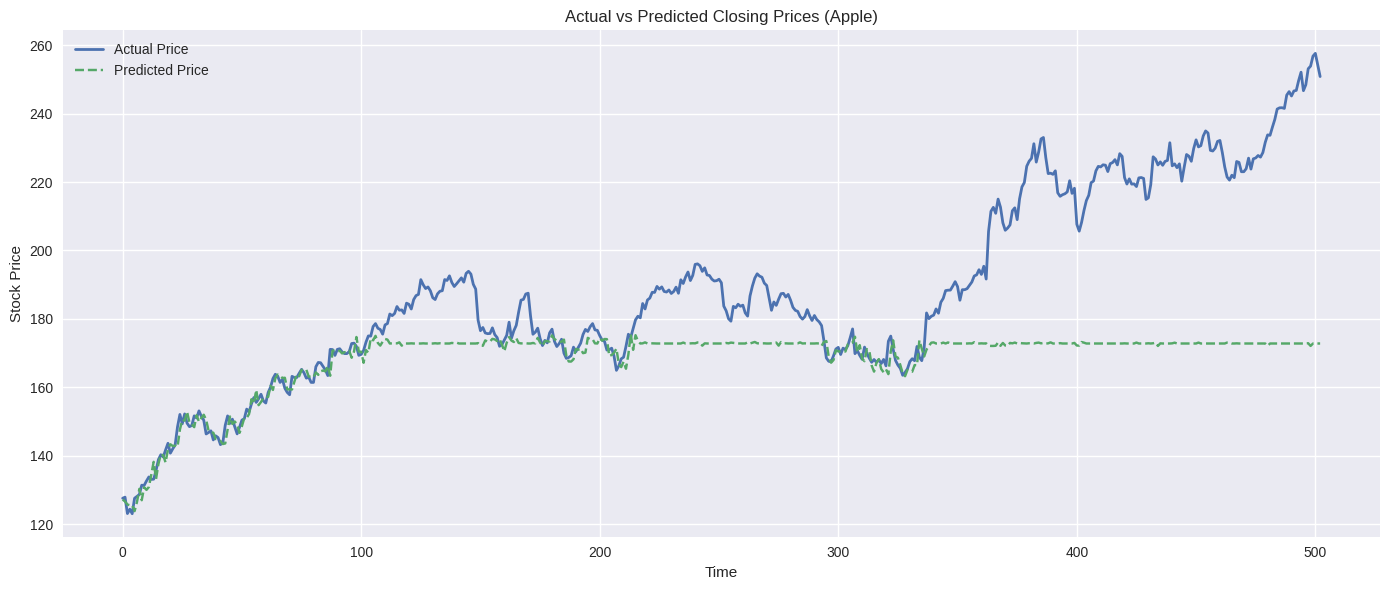


Feature Importance:
Price   Ticker
High    AAPL      0.576100
Open    AAPL      0.244542
Low     AAPL      0.179075
Volume  AAPL      0.000284
dtype: float64


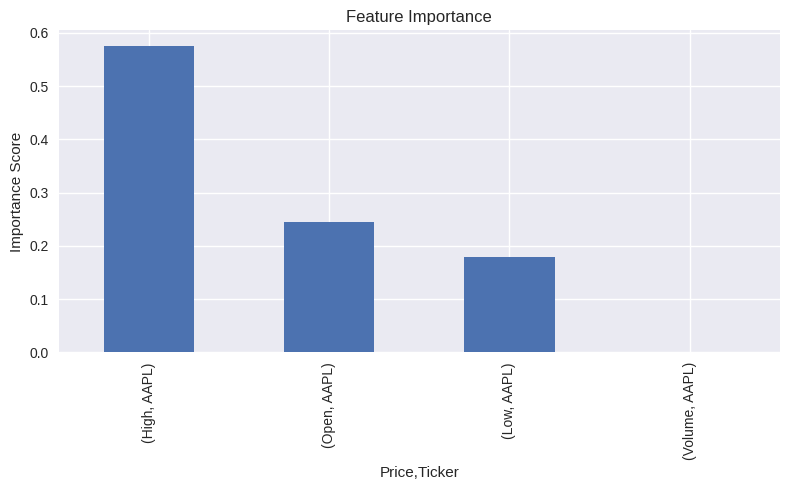

In [2]:

# 1. Import Required Libraries

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use("seaborn-v0_8")
np.random.seed(42)

# 2. Fetch Historical Stock Data

ticker_symbol = "AAPL"  # Apple stock
data = yf.download(ticker_symbol, start="2015-01-01", end="2024-12-31")

# Keep relevant features
data = data[['Open', 'High', 'Low', 'Volume', 'Close']]

# Create target variable (Next day's Close)
data['Target'] = data['Close'].shift(-1)

# Remove last row with NaN target
data.dropna(inplace=True)

print("Dataset Shape:", data.shape)
print("\nFirst 5 Rows:")
print(data.head())

# 3. Feature & Target Separation

X = data[['Open', 'High', 'Low', 'Volume']]
y = data['Target']

# Time-series split (no shuffling)
split_index = int(len(data) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

# 4. Model Training

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# 5. Predictions

predictions = model.predict(X_test)

# 6. Model Evaluation

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("\nModel Performance:")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

# 7. Visualization

plt.figure(figsize=(14,6))
plt.plot(y_test.values, label="Actual Price", linewidth=2)
plt.plot(predictions, label="Predicted Price", linestyle='--')
plt.title("Actual vs Predicted Closing Prices (Apple)")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.tight_layout()
plt.show()

# 8. Feature Importance

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nFeature Importance:")
print(feature_importance)

plt.figure(figsize=(8,5))
feature_importance.plot(kind='bar')
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

### 3. Manual and Real-Time Testing

This cell demonstrates how to use the trained model for making predictions on new data:

*   **Manual Testing**: Defines three hypothetical stock market scenarios (bullish, bearish, high volatility) and uses the model to predict their next-day closing prices.
*   **Real Data Sanity Check**: Applies the model to the last available data point in the test set to predict the next day's close and compares it against the actual value, highlighting the absolute prediction error.

In [3]:

# 9. Manual Testing on Custom Examples

print("\n================ Manual Test Predictions ================\n")

# Example 1: Slightly bullish day
example_1 = pd.DataFrame({
    'Open': [190],
    'High': [195],
    'Low': [188],
    'Volume': [75000000]
})

pred_1 = model.predict(example_1)[0]
print(f"Example 1 Prediction (Bullish Day): ${pred_1:.2f}")


# Example 2: Bearish day with lower high
example_2 = pd.DataFrame({
    'Open': [175],
    'High': [178],
    'Low': [170],
    'Volume': [90000000]
})

pred_2 = model.predict(example_2)[0]
print(f"Example 2 Prediction (Bearish Day): ${pred_2:.2f}")


# Example 3: High volatility day
example_3 = pd.DataFrame({
    'Open': [200],
    'High': [210],
    'Low': [185],
    'Volume': [120000000]
})

pred_3 = model.predict(example_3)[0]
print(f"Example 3 Prediction (High Volatility): ${pred_3:.2f}")

# 10. Real Data Sanity Check (Last Known Day)


last_known_features = X_test.iloc[-1:].copy()
actual_price = y_test.iloc[-1]

predicted_price = model.predict(last_known_features)[0]

print("\n================ Real Market Check ================\n")
print(f"Actual Next Day Close : ${actual_price:.2f}")
print(f"Model Predicted Close : ${predicted_price:.2f}")
print(f"Absolute Error        : ${abs(actual_price - predicted_price):.2f}")


================ Manual Test Predictions ================

Example 1 Prediction (Bullish Day): $173.17


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


Example 2 Prediction (Bearish Day): $169.63
Example 3 Prediction (High Volatility): $172.19


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(



================ Real Market Check ================

Actual Next Day Close : $250.83
Model Predicted Close : $172.80
Absolute Error        : $78.03
